# Class EDA — profiling the engineered behavioural dataset

This notebook is **analysis only**: it reads the artifacts produced by
`ClassEngineering.ipynb` and never rebuilds them. The pipeline writes three files
into `KKBoxData/`:

| file | content |
|------|---------|
| `events_engineered.parquet` | one row per `(msno, E)` expiry event with the label, behavioural, transaction, history, prior-renewal, horizon and split columns |
| `events_daily_panel.parquet` | long-format daily listening sequences for the GRU/LSTM model |
| `feature_manifest.json` | the modelling contract (feature groups, targets, split columns, horizons) |

The four-class **label** is built from a **total-volume ratio**
`vol_ratio = post_total_secs / pre_total_secs` over the 30-day windows either side
of each expiry `E`: a renewed member is **CONTRACTION** below `0.50`, **EXPANSION**

above `1.50`, and **STABLE** in between (a renewer with zero post-window volume iscross-validation / hold-out / walk-forward splits, and the daily sequence panel).

forced to CONTRACTION); non-renewers are **CHURN**; members without ≥7 pre-window**new** engineered steps (prior-renewal history, time-before-renewal horizons,

listening days are **INSUFFICIENT_DATA** and excluded from modelling. TheSections 1–7 reproduce the post-construction profiling; sections 8–11 cover the

`0.50 / 1.50` band is calibrated so STABLE ≈ 60% of the core cohort, and there is

**no post-window gate** — the volume ratio needs no post-window denominator, sorenewers with sparse post-activity are labelled directly rather than dropped.

## 0. Setup — load the engineered artifacts

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA  = Path('KKBoxData')
PLOTS = Path('FinalPlots'); PLOTS.mkdir(exist_ok=True)
SEED  = 42
sns.set_style('whitegrid')

events   = pd.read_parquet(DATA / 'events_engineered.parquet')
manifest = json.loads((DATA / 'feature_manifest.json').read_text())

CLASS_ORDER = manifest['class_order']
CORE_ORDER  = [c for c in CLASS_ORDER if c != 'INSUFFICIENT_DATA']
HORIZONS    = manifest['horizons']
PALETTE = {
    'CHURN':             '#d62728',
    'CONTRACTION':       '#ff7f0e',
    'STABLE':            '#7f7f7f',
    'EXPANSION':         '#2ca02c',
    'INSUFFICIENT_DATA': '#cccccc',
}
core_mask = events['label'] != 'INSUFFICIENT_DATA'
core = events[core_mask]

def save_fig(name):
    plt.savefig(PLOTS / f'{name}.png', dpi=150, bbox_inches='tight')

print(f'events:     {events.shape[0]:,} rows x {events.shape[1]} cols')
print(f'modellable: {core_mask.sum():,} ({core_mask.mean():.1%})')
print('manifest sections:', list(manifest))

events:     6,133,147 rows x 73 cols
modellable: 3,784,500 (61.7%)
manifest sections: ['created', 'n_events', 'n_modellable', 'class_order', 'id_cols', 'split_cols', 'targets', 'leakage_cols', 'feature_groups', 'base_features', 'horizons', 'horizon_features', 'engagement_history', 'sequence_panel', 'splits', 'data_files']


## 1. Dataset shape, memory & headline numbers

In [2]:
mem = events.memory_usage(deep=True).sum() / 1e6
sizes = events.groupby('msno').size()
print(f'In-memory size:   {mem:,.0f} MB')
print(f'Unique users:     {events["msno"].nunique():,}')
print(f'Events per user:  mean {sizes.mean():.2f}, max {sizes.max()}')
print(f'Overall renewal:  {events["renewed"].mean():.1%}')
print(f'\nColumn dtypes:')
print(events.dtypes.value_counts().rename('n_columns').to_frame())
events[['pre_rate', 'post_rate', 'vol_ratio', 'n_hist_txns',
        'prior_renewal_rate']].describe().round(2)

In-memory size:   4,717 MB
Unique users:     1,507,727
Events per user:  mean 4.07, max 27
Overall renewal:  91.4%

Column dtypes:
                n_columns
float64                43
int64                  14
datetime64[ns]          5
object                  4
int8                    4
int32                   3


,pre_rate,post_rate,vol_ratio,n_hist_txns,prior_renewal_rate
count,4717446.00,4474895.00,4717446.00,6130880.00,6133147.00
mean,6443.11,6428.34,6.51,13.06,0.93
std,6157.86,6186.26,2507.18,8.07,0.22
min,0.00,0.00,0.00,1.00,0.00
25%,2840.47,2829.63,0.51,6.00,0.96
50%,4764.54,4769.73,0.90,13.00,1.00
75%,7821.63,7807.86,1.36,20.00,1.00
max,86400.00,86400.00,3549847.73,244.00,1.00


## 2. Missingness by class

Which features are systematically absent for which outcome. Demographic gaps are user-level; behavioural NaNs trace the label logic: `post_rate` is undefined when a member has no post-window listening days, while `vol_ratio` is undefined only when there is no pre-window volume to form the baseline ratio.

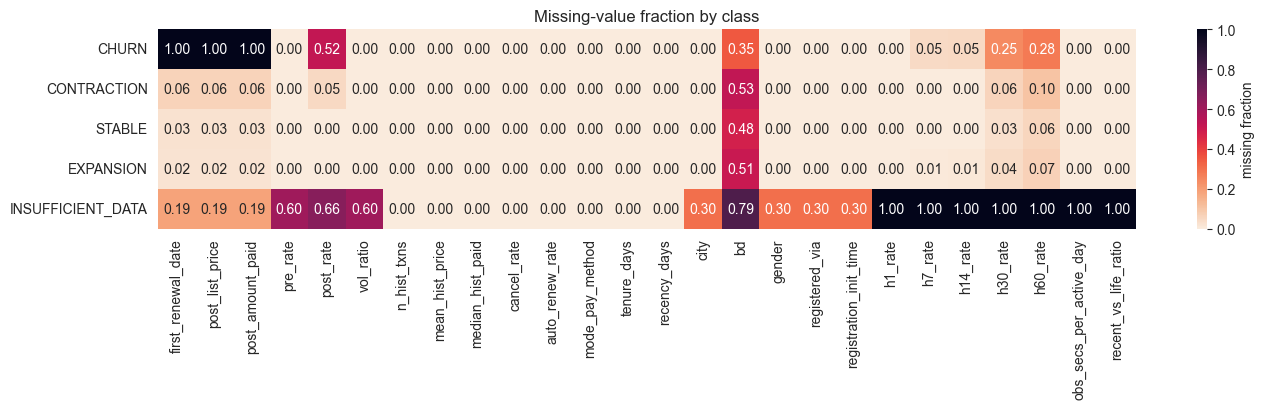

In [3]:
feat_cols = [c for c in events.columns if c not in ('msno', 'E')]
miss = events.groupby('label')[feat_cols].apply(lambda d: d.isna().mean()).reindex(CLASS_ORDER)
miss = miss.loc[:, (miss > 0).any(axis=0)]            # keep only columns with any missingness
fig, ax = plt.subplots(figsize=(min(1 + 0.5 * miss.shape[1], 18), 4.2))
sns.heatmap(miss, annot=True, fmt='.2f', cmap='rocket_r',
            cbar_kws={'label': 'missing fraction'}, ax=ax)
ax.set_title('Missing-value fraction by class'); ax.set_xlabel(''); ax.set_ylabel('')
plt.tight_layout(); save_fig('13_1_missingness_by_class'); plt.show()

## 3. Numeric feature distributions

Marginal shapes of the core numeric predictors (log counts; heavy tails clipped at the 99th pct where noted).

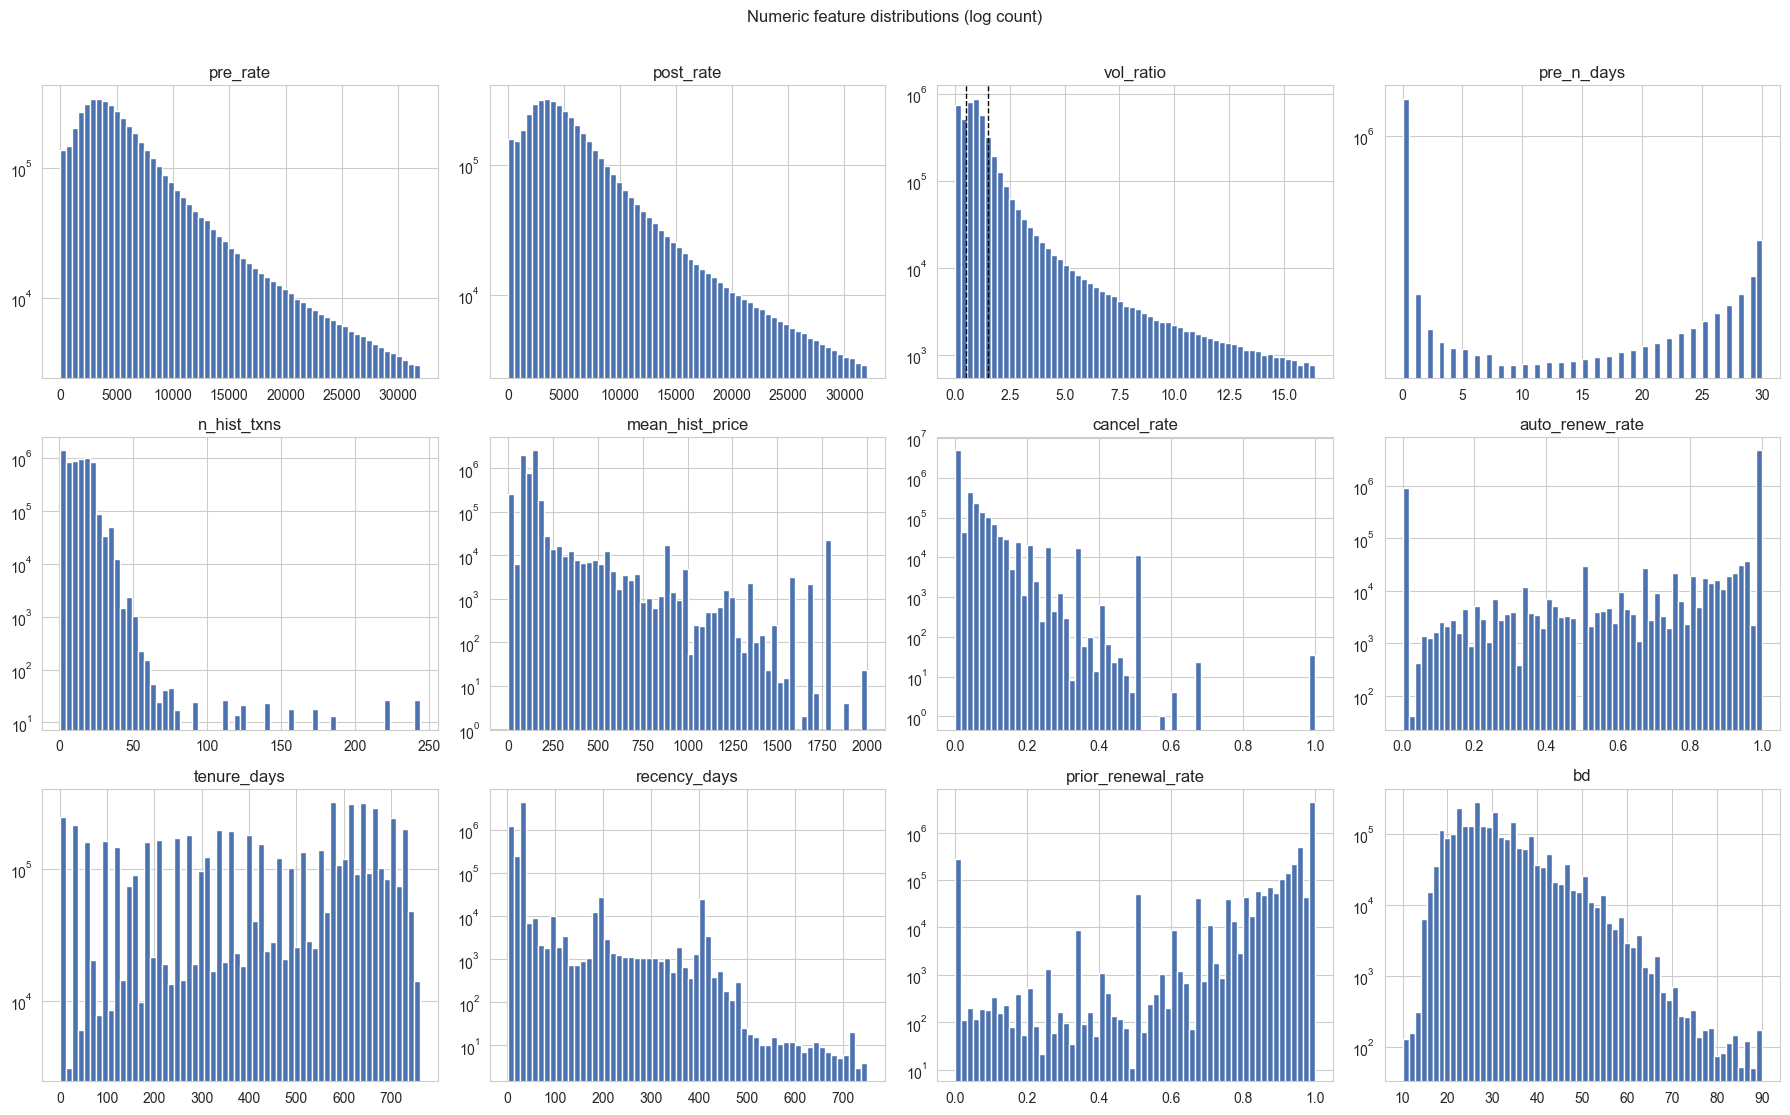

In [4]:
num_cols = ['pre_rate', 'post_rate', 'vol_ratio', 'pre_n_days', 'n_hist_txns',
            'mean_hist_price', 'cancel_rate', 'auto_renew_rate', 'tenure_days',
            'recency_days', 'prior_renewal_rate', 'bd']
num_cols = [c for c in num_cols if c in events.columns]
fig, axes = plt.subplots(3, 4, figsize=(18, 11))
for ax, c in zip(axes.ravel(), num_cols):
    s = events[c].replace([np.inf, -np.inf], np.nan).dropna()
    if c in ('vol_ratio', 'pre_rate', 'post_rate'):
        s = s[s < s.quantile(0.99)]
    ax.hist(s, bins=60, color='#4c72b0')
    if c == 'vol_ratio':
        for cut in (0.50, 1.50):
            ax.axvline(cut, color='k', ls='--', lw=1)
    ax.set_title(c); ax.set_yscale('log')
for ax in axes.ravel()[len(num_cols):]:
    ax.axis('off')
plt.suptitle('Numeric feature distributions (log count)', y=1.01)
plt.tight_layout(); save_fig('13_2_numeric_distributions'); plt.show()

## 4. Class-conditional behavioural distributions

Do the engineered features actually separate the four outcomes? Outliers hidden; `vol_ratio` (total post/pre listening volume) clipped at the 99th pct, with the `0.50 / 1.50` label cuts marked.

/var/folders/pg/h9ytyf2n687_pln_95qm1wl00000gn/T/ipykernel_65830/4131511391.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='label', y=c, order=CORE_ORDER, palette=PALETTE,
/var/folders/pg/h9ytyf2n687_pln_95qm1wl00000gn/T/ipykernel_65830/4131511391.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='label', y=c, order=CORE_ORDER, palette=PALETTE,
/var/folders/pg/h9ytyf2n687_pln_95qm1wl00000gn/T/ipykernel_65830/4131511391.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='label', y=c, order=CORE_ORDER, 

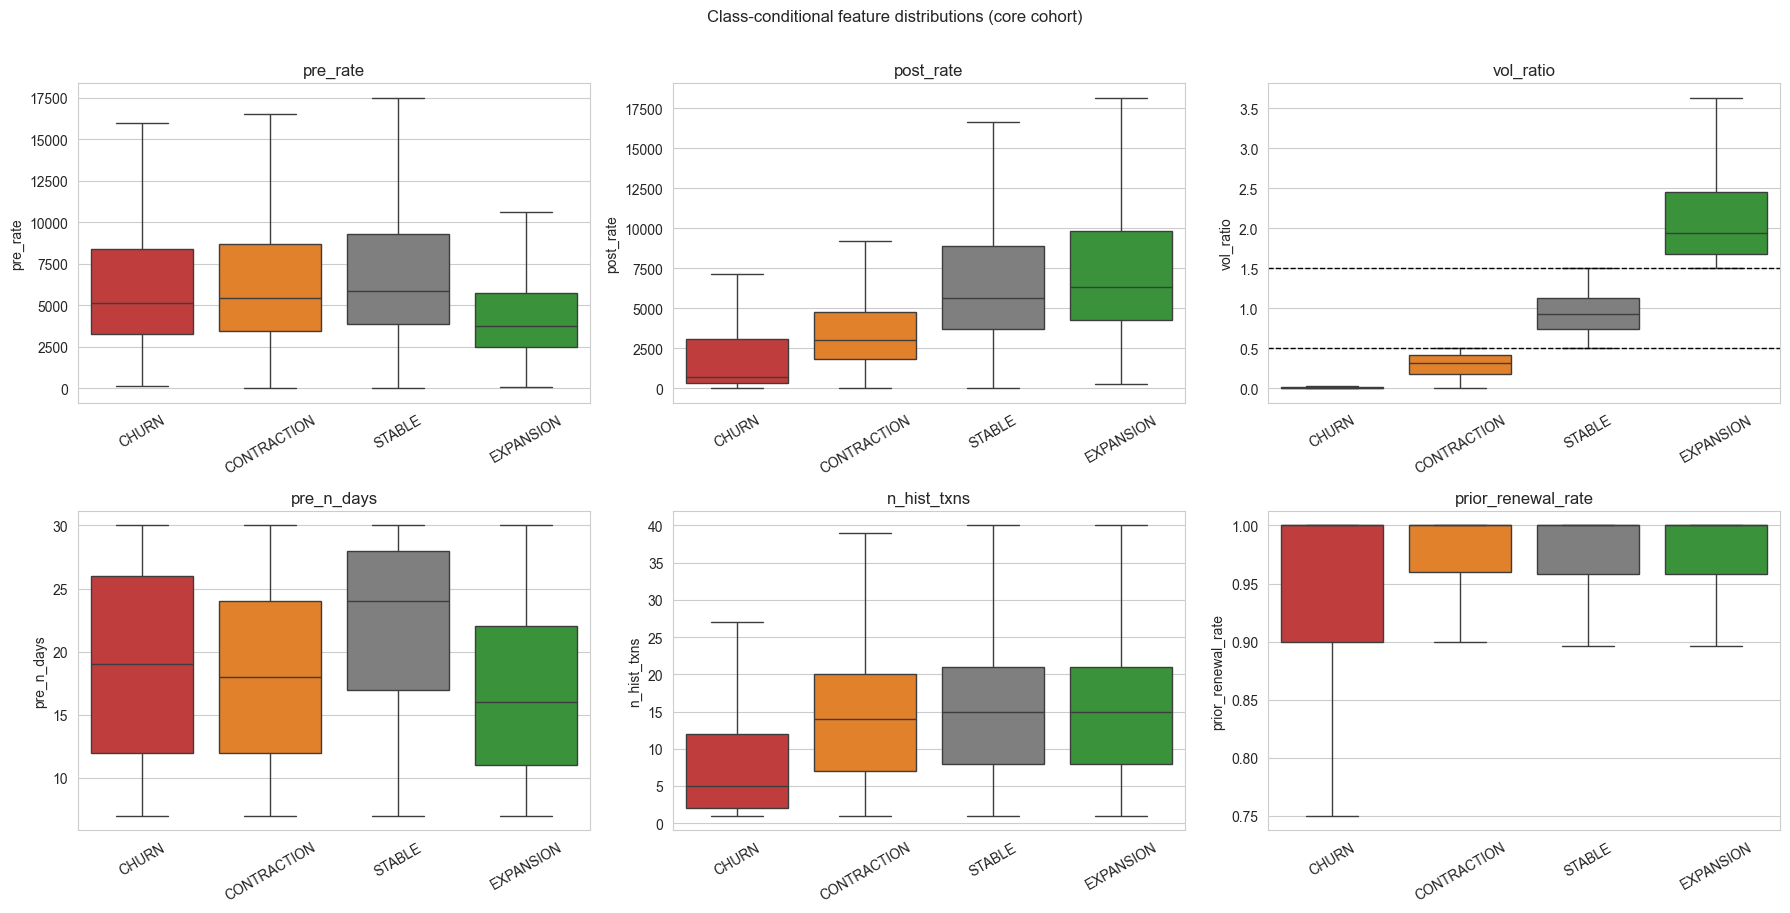

In [5]:
box_feats = ['pre_rate', 'post_rate', 'vol_ratio', 'pre_n_days',
             'n_hist_txns', 'prior_renewal_rate']
box_feats = [c for c in box_feats if c in events.columns]
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, c in zip(axes.ravel(), box_feats):
    d = core[['label', c]].copy()
    d[c] = d[c].replace([np.inf, -np.inf], np.nan)
    if c == 'vol_ratio':
        d = d[d[c] < d[c].quantile(0.99)]
    sns.boxplot(data=d, x='label', y=c, order=CORE_ORDER, palette=PALETTE,
                ax=ax, showfliers=False)
    if c == 'vol_ratio':
        for cut in (0.50, 1.50):
            ax.axhline(cut, color='k', ls='--', lw=1)
    ax.set_title(c); ax.set_xlabel(''); ax.tick_params(axis='x', rotation=30)
plt.suptitle('Class-conditional feature distributions (core cohort)', y=1.01)
plt.tight_layout(); save_fig('13_3_class_conditional_boxplots'); plt.show()

## 5. Categorical class composition

Class mix within the most common demographic / payment levels.

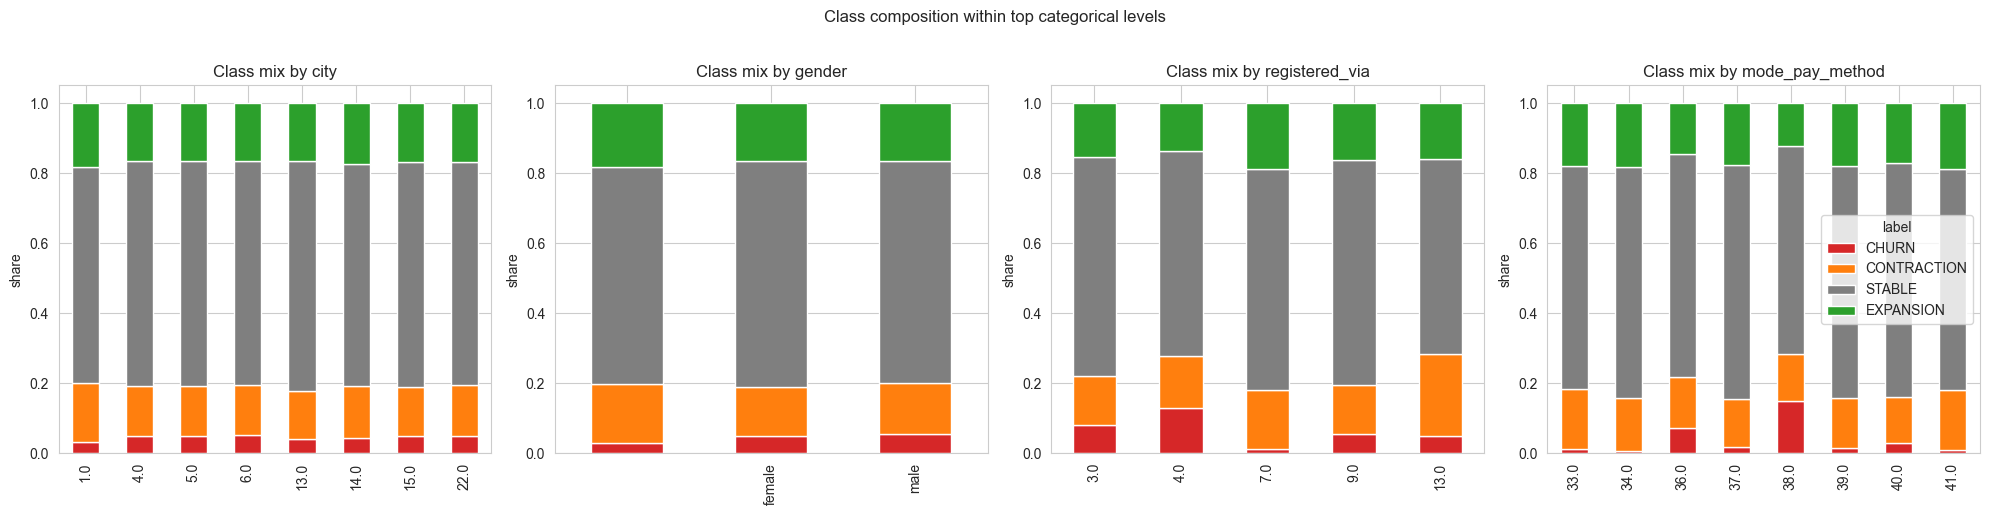

In [6]:
cat_cols = [c for c in ['city', 'gender', 'registered_via', 'mode_pay_method']
            if c in events.columns]
fig, axes = plt.subplots(1, len(cat_cols), figsize=(5 * len(cat_cols), 5))
if len(cat_cols) == 1:
    axes = [axes]
for ax, c in zip(axes, cat_cols):
    top = core[c].value_counts().head(8).index
    d = core[core[c].isin(top)]
    ct = pd.crosstab(d[c], d['label'], normalize='index').reindex(columns=CORE_ORDER)
    ct.plot(kind='bar', stacked=True, color=[PALETTE[k] for k in CORE_ORDER],
            ax=ax, legend=(ax is axes[-1]))
    ax.set_title(f'Class mix by {c}'); ax.set_xlabel(''); ax.set_ylabel('share')
plt.suptitle('Class composition within top categorical levels', y=1.02)
plt.tight_layout(); save_fig('13_4_categorical_class_composition'); plt.show()

## 6. Feature correlation (Spearman)

Rank correlation across the numeric block on a sampled core cohort, to flag redundant predictors before modelling.

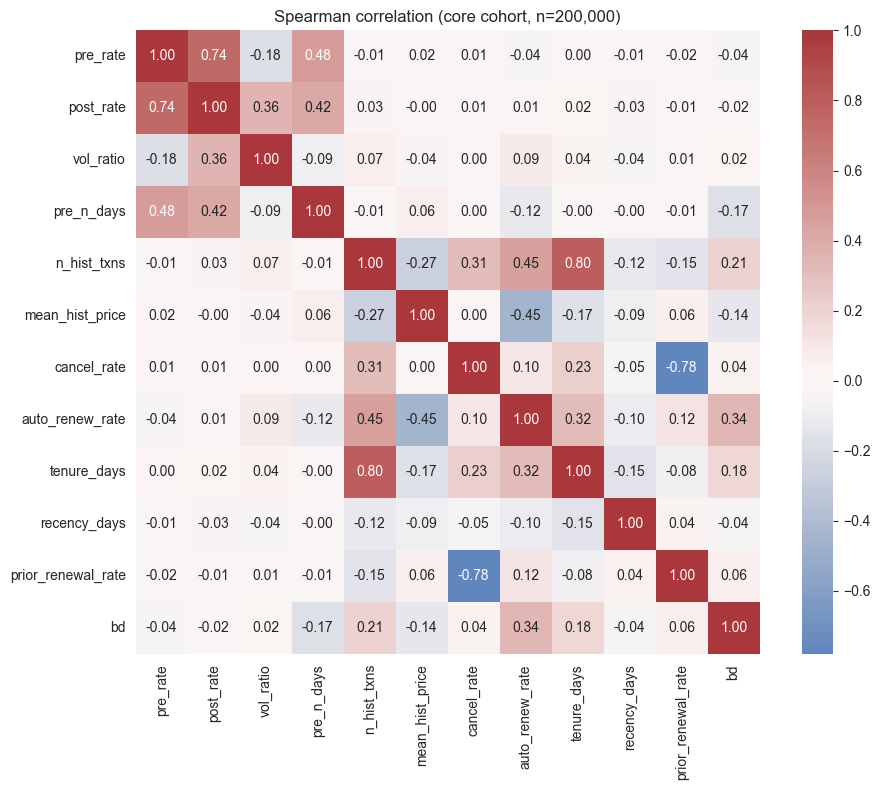

In [7]:
corr_cols = [c for c in num_cols if c in core.columns]
samp = core[corr_cols].replace([np.inf, -np.inf], np.nan).dropna()
if len(samp) > 200_000:
    samp = samp.sample(200_000, random_state=SEED)
corr = samp.corr(method='spearman')
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0, square=True, ax=ax)
ax.set_title(f'Spearman correlation (core cohort, n={len(samp):,})')
plt.tight_layout(); save_fig('13_5_spearman_correlation'); plt.show()

## 7. User state-transition matrix

For users with multiple expiry events, where does each behavioural state move next? The diagonal is persistence; off-diagonal mass is the churn / contraction / expansion dynamics the model must anticipate.

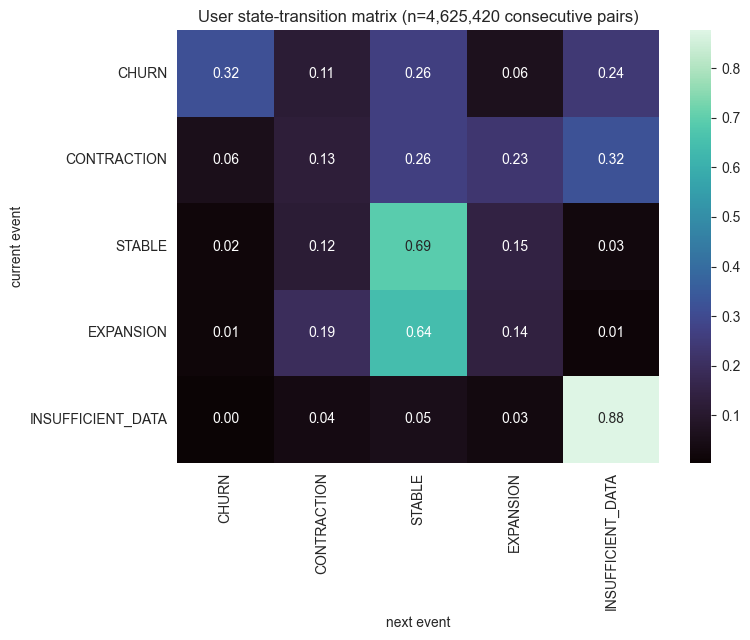

In [8]:
ev = events.sort_values(['msno', 'E']).copy()
ev['next_label'] = ev.groupby('msno')['label'].shift(-1)
pairs = ev.dropna(subset=['next_label'])
tm = pd.crosstab(pairs['label'], pairs['next_label'], normalize='index')
tm = tm.reindex(index=CLASS_ORDER, columns=CLASS_ORDER)
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(tm, annot=True, fmt='.2f', cmap='mako', ax=ax)
ax.set_title(f'User state-transition matrix (n={len(pairs):,} consecutive pairs)')
ax.set_xlabel('next event'); ax.set_ylabel('current event')
plt.tight_layout(); save_fig('13_6_user_transition_matrix'); plt.show()

## 8. Prior-renewal history features

`n_prior_renewals`, `n_prior_cancels`, `n_prior_autorenew` and `prior_renewal_rate`
are strictly **point-in-time** counts of a user's transactions *before* the expiry
event `E`, so they carry the predictive value of identity without leaking the
outcome. We expect committed renewers (STABLE / EXPANSION) to carry richer prior
histories than churners.

/var/folders/pg/h9ytyf2n687_pln_95qm1wl00000gn/T/ipykernel_65830/984084482.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=core, x='label', y='n_prior_renewals', order=CORE_ORDER,


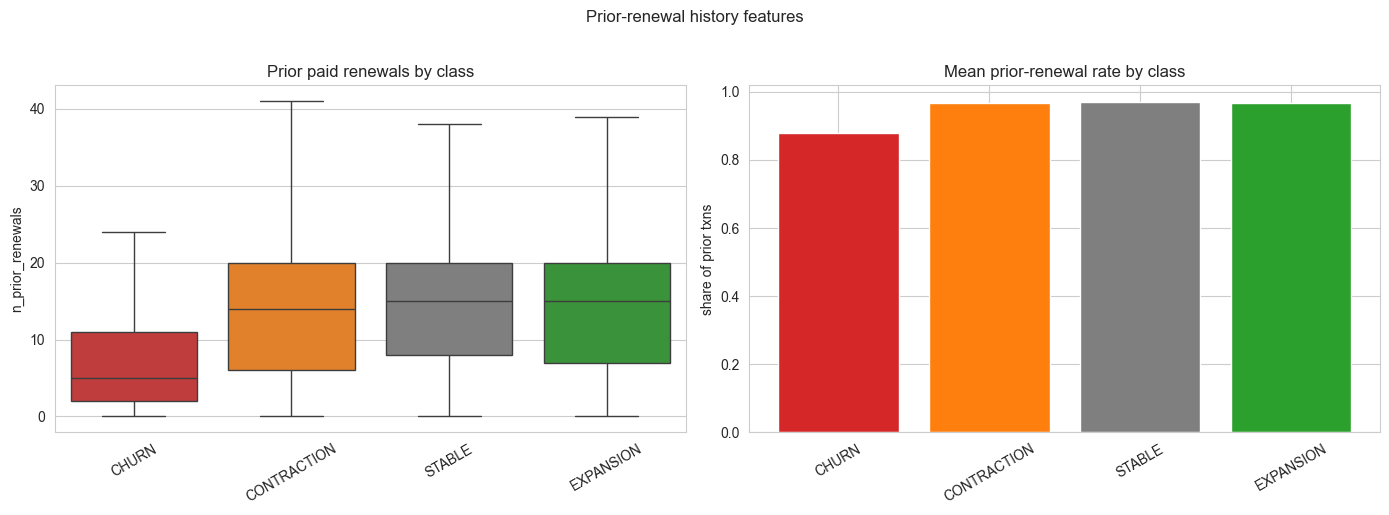

             n_prior_renewals  n_prior_cancels  n_prior_autorenew  \
label                                                               
CHURN                    7.13             0.28               3.82   
CONTRACTION             13.23             0.27              12.26   
STABLE                  14.17             0.29              12.95   
EXPANSION               14.02             0.29              13.20   

             prior_renewal_rate  
label                            
CHURN                      0.88  
CONTRACTION                0.97  
STABLE                     0.97  
EXPANSION                  0.97  


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=core, x='label', y='n_prior_renewals', order=CORE_ORDER,
            palette=PALETTE, ax=axes[0], showfliers=False)
axes[0].set_title('Prior paid renewals by class'); axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)
g = core.groupby('label')['prior_renewal_rate'].mean().reindex(CORE_ORDER)
axes[1].bar(g.index, g.values, color=[PALETTE[k] for k in CORE_ORDER])
axes[1].set_title('Mean prior-renewal rate by class'); axes[1].set_ylabel('share of prior txns')
axes[1].tick_params(axis='x', rotation=30)
plt.suptitle('Prior-renewal history features', y=1.02)
plt.tight_layout(); save_fig('13_7_prior_renewal_by_class'); plt.show()

print(core.groupby('label')[['n_prior_renewals', 'n_prior_cancels',
                             'n_prior_autorenew', 'prior_renewal_rate']]
      .mean().reindex(CORE_ORDER).round(2))

## 8b. Recent engagement vs observed baseline

`obs_secs_per_active_day` is each user's mean listening intensity over **all**
observed pre-`E` log days, and
`recent_vs_life_ratio = pre_rate / obs_secs_per_active_day` contrasts the recent
30-day window against that personal baseline. Values `< 1` mean the user is
**cooling off** relative to their own norm — expected to be most pronounced for
CHURN and CONTRACTION. The baseline is left-censored by the `user_logs` date
range, so it reflects the *observed* history rather than the member's literal
lifetime.

/var/folders/pg/h9ytyf2n687_pln_95qm1wl00000gn/T/ipykernel_65830/2663408238.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='label', y='recent_vs_life_ratio', order=CORE_ORDER,


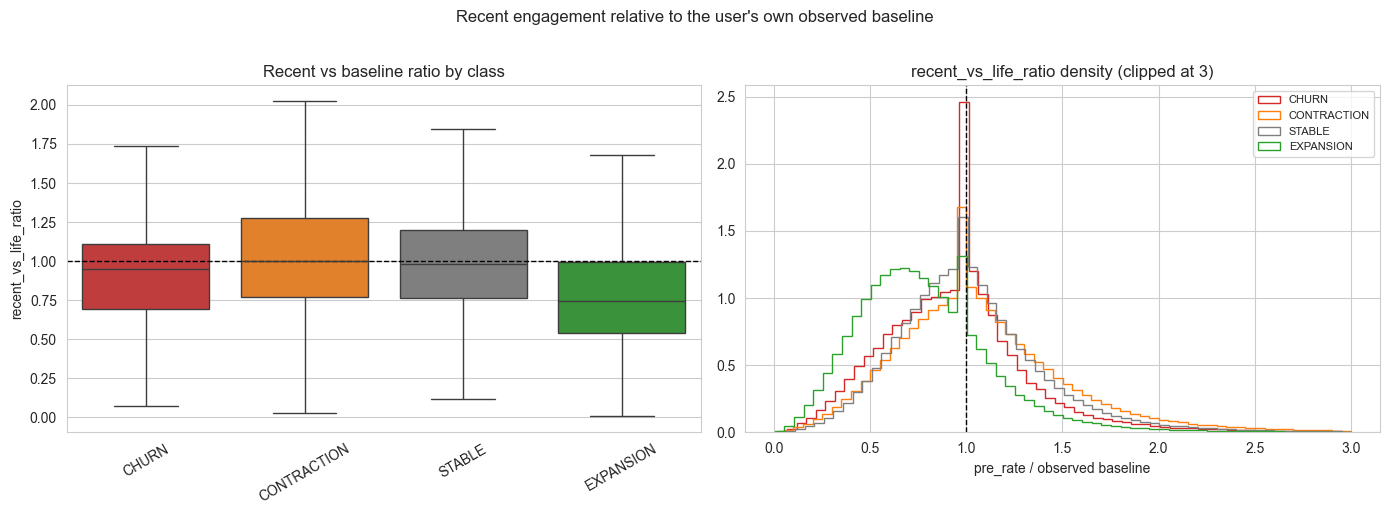

Baseline coverage (non-null): 61.7%
             obs_secs_per_active_day  recent_vs_life_ratio
label                                                     
CHURN                        5940.04                  0.95
CONTRACTION                  5456.83                  1.01
STABLE                       6196.72                  0.99
EXPANSION                    5273.59                  0.75


In [10]:
# Recent 30-day intensity vs each user's observed long-run baseline.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
d = core[['label', 'recent_vs_life_ratio']].replace([np.inf, -np.inf], np.nan).dropna()
d = d[d['recent_vs_life_ratio'] < d['recent_vs_life_ratio'].quantile(0.99)]
sns.boxplot(data=d, x='label', y='recent_vs_life_ratio', order=CORE_ORDER,
            palette=PALETTE, ax=axes[0], showfliers=False)
axes[0].axhline(1.0, color='k', ls='--', lw=1)
axes[0].set_title('Recent vs baseline ratio by class'); axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)
for cls in CORE_ORDER:
    s = core.loc[core['label'] == cls, 'recent_vs_life_ratio'].replace([np.inf, -np.inf], np.nan).dropna()
    s = s[s < 3]
    axes[1].hist(s, bins=60, histtype='step', density=True, color=PALETTE[cls], label=cls)
axes[1].axvline(1.0, color='k', ls='--', lw=1)
axes[1].set_title('recent_vs_life_ratio density (clipped at 3)')
axes[1].set_xlabel('pre_rate / observed baseline'); axes[1].legend(fontsize=8)
plt.suptitle("Recent engagement relative to the user's own observed baseline", y=1.02)
plt.tight_layout(); save_fig('13_11_recent_vs_life'); plt.show()

print('Baseline coverage (non-null):', f"{events['obs_secs_per_active_day'].notna().mean():.1%}")
print(core.groupby('label')[['obs_secs_per_active_day', 'recent_vs_life_ratio']]
      .median().reindex(CORE_ORDER).round(2))

## 9. Time-before-renewal horizon features

For each horizon `h` in `HORIZONS` the pipeline summarises a 30-day observation
window **ending `h` days before** the expiry, while the label stays fixed at `E`.
`h{h}_active` is the active-day ratio and `h{h}_rate` the mean seconds per active
day. Tracking these across horizons previews how much behavioural signal survives
as the prediction is pushed earlier — the core of the time-before-renewal experiment.

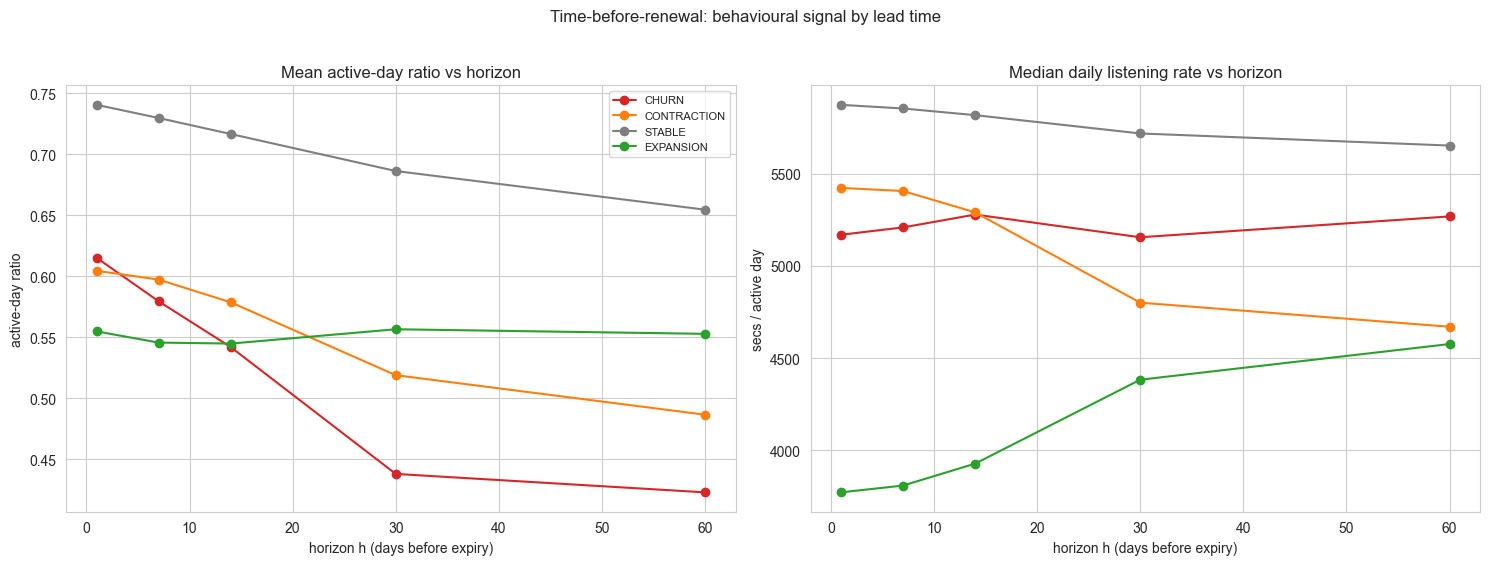

     active_day_ratio  has_any_activity
h1              0.682             1.000
h7              0.671             0.997
h14             0.658             0.995
h30             0.628             0.953
h60             0.601             0.924


In [11]:
rate_cols   = [f'h{h}_rate'   for h in HORIZONS]
active_cols = [f'h{h}_active' for h in HORIZONS]
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for cls in CORE_ORDER:
    d = core[core['label'] == cls]
    axes[0].plot(HORIZONS, [d[c].mean() for c in active_cols],
                 marker='o', color=PALETTE[cls], label=cls)
    axes[1].plot(HORIZONS, [d[c].median() for c in rate_cols],
                 marker='o', color=PALETTE[cls], label=cls)
axes[0].set_title('Mean active-day ratio vs horizon')
axes[0].set_xlabel('horizon h (days before expiry)'); axes[0].set_ylabel('active-day ratio')
axes[0].legend(fontsize=8)
axes[1].set_title('Median daily listening rate vs horizon')
axes[1].set_xlabel('horizon h (days before expiry)'); axes[1].set_ylabel('secs / active day')
plt.suptitle('Time-before-renewal: behavioural signal by lead time', y=1.02)
plt.tight_layout(); save_fig('13_8_horizon_signal_by_class'); plt.show()

cover = pd.DataFrame({
    'active_day_ratio': [core[f'h{h}_active'].mean() for h in HORIZONS],
    'has_any_activity': [(core[f'h{h}_ndays'] > 0).mean() for h in HORIZONS],
}, index=[f'h{h}' for h in HORIZONS]).round(3)
print(cover)

## 10. Cross-validation, hold-out & walk-forward splits

`user_fold` is a deterministic user-grouped $K$-fold assignment (no user spans two
folds, so the prior-renewal features cannot leak across folds); `is_holdout`
reserves a fixed set of users for a final untouched test; `month_idx` orders expiry
months for walk-forward validation. The folds and months should be class-balanced.

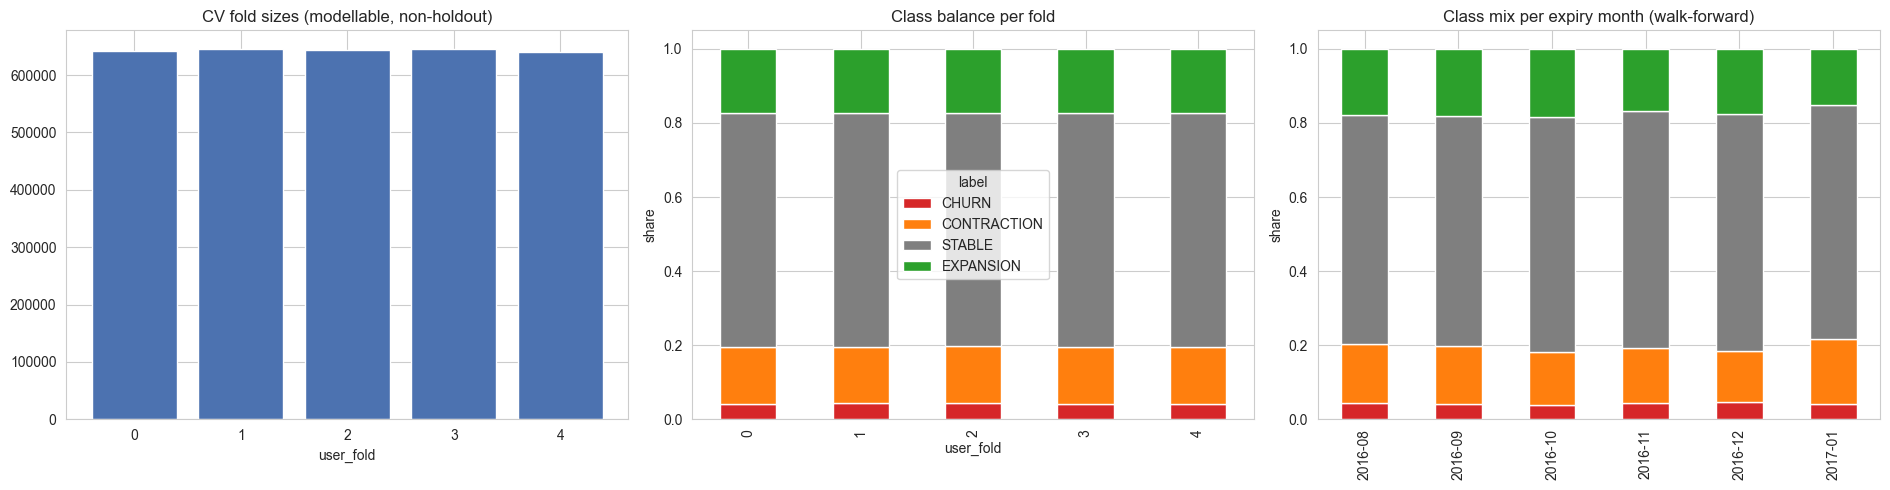

Hold-out users:         226,537
Hold-out share of rows: 15.0%
Modellable events:      3,784,500


In [12]:
msk = (events['is_modellable'] == 1) & (events['user_fold'] >= 0)
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

fc = events.loc[msk, 'user_fold'].value_counts().sort_index()
axes[0].bar(fc.index.astype(str), fc.values, color='#4c72b0')
axes[0].set_title('CV fold sizes (modellable, non-holdout)'); axes[0].set_xlabel('user_fold')

cb = pd.crosstab(events.loc[msk, 'user_fold'], events.loc[msk, 'label'],
                 normalize='index').reindex(columns=CORE_ORDER)
cb.plot(kind='bar', stacked=True, color=[PALETTE[k] for k in CORE_ORDER], ax=axes[1])
axes[1].set_title('Class balance per fold'); axes[1].set_xlabel('user_fold'); axes[1].set_ylabel('share')

wf = pd.crosstab(events.loc[events['is_modellable'] == 1, 'expiry_month'],
                 events.loc[events['is_modellable'] == 1, 'label'],
                 normalize='index').reindex(columns=CORE_ORDER)
wf.plot(kind='bar', stacked=True, color=[PALETTE[k] for k in CORE_ORDER], ax=axes[2], legend=False)
axes[2].set_title('Class mix per expiry month (walk-forward)'); axes[2].set_xlabel(''); axes[2].set_ylabel('share')
plt.tight_layout(); save_fig('13_9_split_diagnostics'); plt.show()

print('Hold-out users:        ', f"{events.loc[events['is_holdout'] == 1, 'msno'].nunique():,}")
print('Hold-out share of rows:', f"{events['is_holdout'].mean():.1%}")
print('Modellable events:     ', f"{int((events['is_modellable'] == 1).sum()):,}")

## 11. Daily sequence panel

`events_daily_panel.parquet` is the long-format input for the sequence model: one
row per `(msno, E, active-day)` over the `SEQ_WINDOW_DAYS` window before expiry,
carrying the daily listening channels. Below: how many active days each event
contributes, and the average listening trajectory as the expiry approaches.

panel rows: 148,916,193  |  events with >=1 active day: 3,784,500


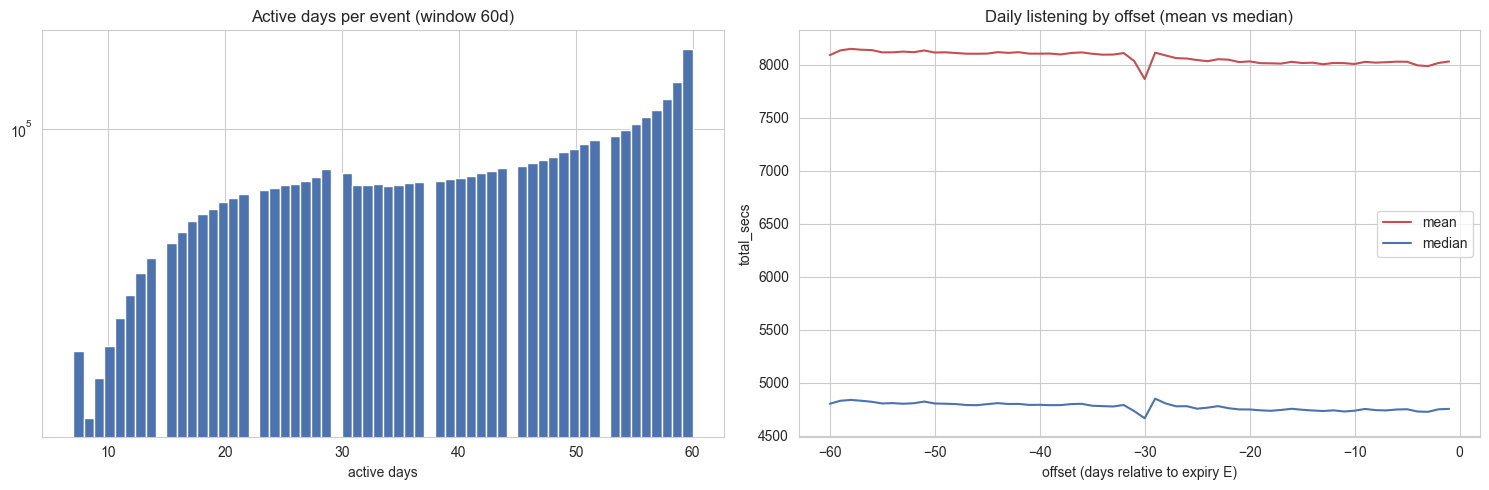

In [13]:
panel = pd.read_parquet(DATA / 'events_daily_panel.parquet')
n_events = panel.groupby(['msno', 'E']).ngroups
print(f'panel rows: {len(panel):,}  |  events with >=1 active day: {n_events:,}')

adpe = panel.groupby(['msno', 'E']).size()
by_offset = panel.groupby('offset')['total_secs']
prof_mean   = by_offset.mean()
prof_median = by_offset.median()
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].hist(adpe.values, bins=60, color='#4c72b0')
axes[0].set_title(f"Active days per event (window {manifest['sequence_panel']['window_days']}d)")
axes[0].set_xlabel('active days'); axes[0].set_yscale('log')
axes[1].plot(prof_mean.index,   prof_mean.values,   color='#c44e52', label='mean')
axes[1].plot(prof_median.index, prof_median.values, color='#4c72b0', label='median')
axes[1].set_title('Daily listening by offset (mean vs median)')
axes[1].set_xlabel('offset (days relative to expiry E)'); axes[1].set_ylabel('total_secs')
axes[1].legend()
plt.tight_layout(); save_fig('13_10_sequence_panel'); plt.show()